## Matching DP1 Catalogs with Classified Variable Stars (through our collected variable star catalogs) to Create Centralized Catalog (includes objects in all 7 DP1 regions)

### Necessary imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lsst.rsp import get_tap_service

import astropy.units as u
from astropy.table import unique
from astropy.coordinates import SkyCoord
import os

**Load our catalog of variable stars (~900) all located in Fornax dSph region (we will be loading data collected from other regions later)**

**Note - to know how we collected and created this table, see 'VStar_Tables.ipynb' notebook. In addition to that notebook, we have tweaked the table to make ra/dec coordinates of stars, specifically those collected from the Bersier Wood paper, more precise, as many of the original coordinates went up till only 2 decimal points which is not enough to correctly cross-match those sources with DP1. For our methodology on these, see 'AdjustBersierWood.ipynb'**

Hence, that is why the csv file is named 'v_stars_updated.csv'

In [3]:
# get the path of our v_stars catalog we created
path = os.getcwd()
vstars_path = os.path.join(path, 'v_stars_updated.csv')
vstars_path

'/home/aadi-bery/WORK/v_stars_updated.csv'

In [4]:
# read the csv as a pandas dataframe
v_stars_df = pd.read_csv(vstars_path)

In [5]:
v_stars_df.head(10) # we can now see the increased precision of the ra and dec coordinates

,ra,dec,period,Vmag,e_Vmag,Icmag,e_Icmag,E(B-V),source,main category,...,iamp,e_iamp,vamp_sec,e_vamp_sec,bamp_sec,e_bamp_sec,gmag,bpmag,rpmag,bp-rp
0,39.860000,-34.674167,0.37206,21.321,0.028,20.799,0.042,0.025,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,39.457500,-34.407500,0.54365,21.389,0.027,20.755,0.036,0.028,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,39.461667,-34.460000,0.58252,21.346,0.021,20.744,0.035,0.030,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,39.466250,-34.438889,0.58052,21.419,0.023,20.887,0.033,0.029,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,39.470000,-34.770833,0.16459,21.469,0.029,20.560,0.033,0.034,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,39.472500,-34.870833,0.59260,21.344,0.026,20.781,0.035,0.035,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,39.479167,-34.623889,0.40322,21.401,0.026,20.911,0.035,0.035,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,39.483333,-34.458889,0.33797,21.468,0.020,21.101,0.036,0.030,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,39.483750,-34.725556,0.51202,21.544,0.022,20.849,0.036,0.034,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,39.485833,-34.585278,0.54362,21.392,0.022,20.766,0.031,0.035,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# look at distribution of stars from each source once more (for comparison later)
v_stars_df['source'].value_counts()

source
Bersier Wood    624
Braga           212
Gaia             63
Name: count, dtype: int64

In [7]:
# intialize tap service from rubin
service = get_tap_service('tap')

**Understand DP1 diaObject table**

In [8]:
# see the columns in the diaobject table to get an idea of what it contains
query = "SELECT column_name, datatype, description, unit " \
        "FROM tap_schema.columns " \
        "WHERE table_name = 'dp1.DiaObject'"

job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'

Job phase is COMPLETED


In [9]:
r = job.fetch_result().to_table()
r

column_name,datatype,description,unit
str64,str64,str512,str64
dec,double,Declination coordinate of the position of the diaObject at time radecMjdTai.,deg
diaObjectId,long,Unique identifier of this DiaObject.,
g_psfFluxChi2,float,Chi^2 statistic for the scatter of g_psfFlux around g_psfFluxMean,
g_psfFluxErrMean,float,Mean of the diaSource PSF flux errors,nJy
g_psfFluxLinearIntercept,double,y-intercept of a linear model fit to diaSource PSF flux vs time,nJy
g_psfFluxLinearSlope,double,Slope of a linear model fit to diaSource PSF flux vs time,nJy/d
g_psfFluxMAD,float,Median absolute deviation of diaSource PSF flux. Does not include scale factor for comparison to sigma,nJy
g_psfFluxMax,double,Maximum diaSource PSF flux,nJy
g_psfFluxMaxSlope,double,Maximum ratio of time ordered deltaFlux / deltaTime,nJy/d


**Query DP1 DiaObject Table for all objects located in Fornax dSph to use for cross matching with our catalog above**

In [10]:
# now we want to query the fornax dSph region in diaobject
field_filters = ['g', 'r', 'i']
ra_cen = 40.080
dec_cen = -34.450
radius = 1


# search with a 1.5 x 1.5 degree square box to ensure we get all the observations
query = """SELECT diaObjectId, ra, dec, g_psfFluxMean, r_psfFluxMean, i_psfFluxMean,
        g_psfFluxSigma, r_psfFluxSigma, i_psfFluxSigma,
        g_psfFluxChi2, r_psfFluxChi2, i_psfFluxChi2,
        g_psfFluxStetsonJ, r_psfFluxStetsonJ, i_psfFluxStetsonJ,
        g_psfFluxMAD, r_psfFluxMAD, i_psfFluxMAD,
        g_psfFluxNdata, r_psfFluxNdata, i_psfFluxNdata, nDiaSources
        FROM dp1.DiaObject
        WHERE ra BETWEEN 39.33 AND 40.83 
        AND dec BETWEEN -35.20 AND -33.70
        ORDER BY diaObjectId ASC
        """

In [11]:
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Job phase is COMPLETED


In [12]:
# get results
results = job.fetch_result().to_table()
results

diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources
,deg,deg,nJy,nJy,nJy,nJy,nJy,nJy,,,,,,,nJy,nJy,nJy,,,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float32,float64,float64,float64,float32,float32,float32,float64,float64,float64,int64
604061380378624001,39.98445477102133,-34.96470057098531,--,--,-1806.5711669921875,--,--,--,--,--,1.12541e-13,--,--,--,--,--,0.0,--,--,1.0,1
604061380378624002,39.84566754510897,-34.97204578447762,1209.6697998046875,--,--,--,--,--,0.0,--,--,--,--,--,0.0,--,--,1.0,--,--,1
604061380378624003,39.842602703242356,-34.96776692821749,1048.392822265625,--,--,--,--,--,0.0,--,--,--,--,--,0.0,--,--,1.0,--,--,1
604061380378624004,39.878044331753564,-34.957897168114556,3353.673583984375,--,--,--,--,--,0.0,--,--,--,--,--,0.0,--,--,1.0,--,--,1
604061380378624005,39.84773508819411,-34.967208659508636,2848.40966796875,--,--,14147.390625,--,--,460.896,--,--,20.516656490245076,--,--,10003.7,--,--,2.0,--,--,2
604061380378624006,39.88887231174755,-34.985215616679994,-2982.33154296875,--,--,--,--,--,2.33347e-13,--,--,--,--,--,0.0,--,--,1.0,--,--,1
604061380378624007,39.932187195440854,-35.001649137508835,-2678.751708984375,--,--,--,--,--,2.99831e-13,--,--,--,--,--,0.0,--,--,1.0,--,--,1
604061449098100737,39.61911685998628,-35.02573224044808,--,--,-25843.90234375,--,--,--,--,--,1.03539e-12,--,--,--,--,--,0.0,--,--,1.0,1


In [13]:
# convert our results to a pandas df
df_diaobj = results.to_pandas()

In [14]:
# check to see the null values among each column we've recieved
print(df_diaobj.isnull().sum())

diaObjectId              0
ra                       0
dec                      0
g_psfFluxMean        33956
r_psfFluxMean        12674
i_psfFluxMean        13571
g_psfFluxSigma       35735
r_psfFluxSigma       24939
i_psfFluxSigma       24473
g_psfFluxChi2        33956
r_psfFluxChi2        12674
i_psfFluxChi2        13571
g_psfFluxStetsonJ    35735
r_psfFluxStetsonJ    24939
i_psfFluxStetsonJ    24473
g_psfFluxMAD         33956
r_psfFluxMAD         12674
i_psfFluxMAD         13571
g_psfFluxNdata       33956
r_psfFluxNdata       12674
i_psfFluxNdata       13571
nDiaSources              0
dtype: int64


In [15]:
# we can also see just about half of the detected objects have only 1 diaSource detection (presumaly because the fornax was only captured over 2 nights)
df_diaobj['nDiaSources'].value_counts()[:10]

nDiaSources
1     18315
2      5348
3      2590
4      1687
5      1223
6       932
7       707
8       568
9       495
10      431
Name: count, dtype: int64

**Perform Cross-matching using RA/Dec Coordinates and astropy**

In [16]:
# ensure our catalog coordinates in our catalog table are numeric so skycoord works as intended
v_stars_df['ra'] = pd.to_numeric(v_stars_df['ra'], errors='coerce')
v_stars_df['dec'] = pd.to_numeric(v_stars_df['dec'], errors='coerce')

In [17]:
# match coordinates
coords_var = SkyCoord(ra=v_stars_df['ra'].values*u.deg, dec=v_stars_df['dec'].values*u.deg) # create sky coord object for each object in classified table

# create sky coords object for objects returned from DiaObject query (~36000)
coords_dia = SkyCoord(ra=df_diaobj['ra'].values*u.deg, dec=df_diaobj['dec'].values*u.deg)

# make sure this looks as intended
print(coords_var[:5])
print(coords_dia[:5])

<SkyCoord (ICRS): (ra, dec) in deg
    [(39.86      , -34.67416667), (39.4575    , -34.4075    ),
     (39.46166667, -34.46      ), (39.46625   , -34.43888889),
     (39.47      , -34.77083333)]>
<SkyCoord (ICRS): (ra, dec) in deg
    [(39.98445477, -34.96470057), (39.84566755, -34.97204578),
     (39.8426027 , -34.96776693), (39.87804433, -34.95789717),
     (39.84773509, -34.96720866)]>


**Link to astropy diacumentation for method match_to_catalog_sky (astropy.coordinates.SkyCoord.match_to_catalog_sky)**

https://diacs.astropy.org/en/stable/api/astropy.coordinates.SkyCoord.html

**Note: although we have done our part to make coordinates as precise as we can, some of the coordinates of stars in our v_star catalog have less precision (namely those retrieved from Bersier Wood paper)**

Thus, matching within 1 arcsec might be too little to get everything. So we will try **1.5 arcseconds**

In [18]:
# Match to nearest source within 1.5 arcseconds (~0.0004 degrees)
idx, d2d, _ = coords_var.match_to_catalog_sky(coords_dia)
matches = d2d < 1.5 * u.arcsec

In [19]:
# retrieve closest matched stars by coordinate in each respective table
matched_vars = v_stars_df[matches].reset_index(drop=True)
matched_diaobj = df_diaobj.iloc[idx[matches]].reset_index(drop=True)

In [20]:
# see what the matched v_stars look like in our table, 586 were 'matched' to objects captured by Rubin
matched_vars

,ra,dec,period,Vmag,e_Vmag,Icmag,e_Icmag,E(B-V),source,main category,...,iamp,e_iamp,vamp_sec,e_vamp_sec,bamp_sec,e_bamp_sec,gmag,bpmag,rpmag,bp-rp
0,39.860000,-34.674167,0.372060,21.321,0.028,20.799,0.042,0.025,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,39.479167,-34.623889,0.403220,21.401,0.026,20.911,0.035,0.035,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,39.483333,-34.458889,0.337970,21.468,0.020,21.101,0.036,0.030,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,39.483750,-34.725556,0.512020,21.544,0.022,20.849,0.036,0.034,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,39.485833,-34.585278,0.543620,21.392,0.022,20.766,0.031,0.035,Bersier Wood,RRLyrae,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,40.362608,-34.368753,NaN,NaN,NaN,NaN,NaN,NaN,Gaia,LPV,...,NaN,NaN,NaN,NaN,NaN,NaN,17.524929,18.774679,16.431068,2.343611
582,40.441648,-34.291025,NaN,NaN,NaN,NaN,NaN,NaN,Gaia,LPV,...,NaN,NaN,NaN,NaN,NaN,NaN,17.425013,18.622169,16.353251,2.268919
583,40.222196,-34.203659,243.829816,NaN,NaN,NaN,NaN,NaN,Gaia,LPV,...,NaN,NaN,NaN,NaN,NaN,NaN,17.899149,18.981697,16.645916,2.335781
584,39.742913,-34.536605,203.290829,NaN,NaN,NaN,NaN,NaN,Gaia,LPV,...,NaN,NaN,NaN,NaN,NaN,NaN,17.573246,18.800655,16.482256,2.318399


In [21]:
# check the corresponding matches from the diaobjects
matched_diaobj

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources
0,604062754768159712,39.860267,-34.674227,NaN,3478.691162,-1305.055054,NaN,379.962477,1429.338403,NaN,...,NaN,0.613791,3.369749,NaN,106.447998,342.906006,NaN,4.0,5.0,9
1,604063579401880134,39.479486,-34.623980,NaN,-1229.526611,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1
2,604063579401879605,39.483699,-34.459000,NaN,-329.157166,1546.830566,NaN,3877.169434,3205.143786,NaN,...,NaN,13.460100,8.900450,NaN,263.958008,724.005981,NaN,4.0,3.0,7
3,604062892207112473,39.483927,-34.725717,NaN,-1281.013306,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1
4,604063579401879640,39.486279,-34.585293,NaN,-87.496536,NaN,NaN,2722.921631,NaN,NaN,...,NaN,9.305503,NaN,NaN,6.112300,NaN,NaN,3.0,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,604071482141704300,40.362596,-34.368746,-1540.172363,-3628.373779,6850.815430,NaN,5157.325684,11662.703223,0.0,...,NaN,7.982201,10.895440,0.0,1529.000000,6562.870117,1.0,15.0,4.0,20
582,604071413422227518,40.441641,-34.291022,NaN,-2045.072144,10687.918945,NaN,15264.694785,3370.800027,NaN,...,NaN,12.250167,2.588180,NaN,487.434998,1844.449951,NaN,17.0,3.0,20
583,605447039907528727,40.222211,-34.203669,NaN,2056.043701,-815.155823,NaN,5090.153468,14835.050592,NaN,...,NaN,11.339753,18.610866,NaN,2762.120117,9384.839844,NaN,12.0,6.0,18
584,604063510682402825,39.742918,-34.536616,NaN,-192.498489,-1563.211548,NaN,1972.457410,6051.792267,NaN,...,NaN,3.397101,4.798656,NaN,1822.050049,2520.620117,NaN,15.0,8.0,23


### Further Analysis and Cleaning
We are now going to begin to understand which of these matches are actual variable stars (or we are at least mostly confident they are) and filter out any that don't support this assumption. We do this as an extra step of verification to be confident in those matches so that we can apply them to machine learning for classification / clustering

In [22]:
# see the distribution of the matched variable stars based on where we got them from
matched_vars['source'].value_counts()

# 376 / 624 Bersier Wood
# 154 / 212 Braga
# 56 / 62 Gaia (likely due to the precision of coordinates)

source
Bersier Wood    376
Braga           154
Gaia             56
Name: count, dtype: int64

In [23]:
# check the distrubution of star types that were matched
matched_vars['main category'].value_counts()

main category
RRLyrae    454
LPV        116
Cepheid     16
Name: count, dtype: int64

In [24]:
# check to see how much of each column is missing
matched_diaobj.isnull().sum()

diaObjectId            0
ra                     0
dec                    0
g_psfFluxMean        549
r_psfFluxMean         32
i_psfFluxMean        185
g_psfFluxSigma       573
r_psfFluxSigma       111
i_psfFluxSigma       280
g_psfFluxChi2        549
r_psfFluxChi2         32
i_psfFluxChi2        185
g_psfFluxStetsonJ    573
r_psfFluxStetsonJ    111
i_psfFluxStetsonJ    280
g_psfFluxMAD         549
r_psfFluxMAD          32
i_psfFluxMAD         185
g_psfFluxNdata       549
r_psfFluxNdata        32
i_psfFluxNdata       185
nDiaSources            0
dtype: int64

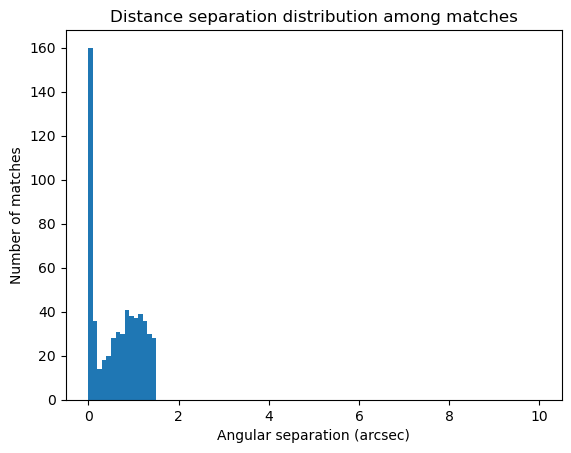

In [25]:
# visualize the distance separation distribution (should peak close to 0)
d2d_matched = d2d[matches].arcsecond

plt.hist(d2d_matched, bins=100, range=(0,10))
plt.xlabel('Angular separation (arcsec)')
plt.ylabel('Number of matches')
plt.title('Distance separation distribution among matches')
plt.show()

In [26]:
# grab section of matched objects which had between 1 arcsec and 1.5 arcsec separation
indices_uncertain = np.where(d2d_matched > 1)[0]

print(len(indices_uncertain))
indices_uncertain

170


array([  1,   2,   4,   5,   6,   9,  12,  15,  16,  18,  20,  21,  22,
        23,  24,  27,  30,  35,  36,  37,  39,  41,  42,  43,  44,  45,
        47,  48,  49,  50,  51,  52,  53,  55,  57,  59,  60,  62,  65,
        69,  73,  79,  81,  82,  83,  84,  85,  86,  88,  90,  91,  92,
        93,  95,  96,  97,  98, 100, 101, 103, 105, 107, 108, 111, 112,
       117, 120, 125, 127, 128, 130, 135, 139, 140, 142, 144, 145, 147,
       149, 150, 151, 153, 159, 167, 169, 180, 183, 185, 187, 189, 191,
       194, 197, 198, 201, 205, 206, 207, 209, 214, 217, 218, 219, 222,
       224, 228, 229, 231, 232, 235, 238, 241, 242, 244, 253, 257, 259,
       262, 264, 269, 271, 273, 274, 275, 277, 280, 281, 285, 286, 287,
       290, 291, 294, 297, 298, 299, 300, 301, 303, 306, 309, 311, 313,
       315, 316, 317, 319, 321, 322, 324, 325, 328, 329, 331, 334, 335,
       337, 338, 339, 345, 347, 352, 353, 354, 355, 356, 358, 362, 368,
       372])

In [27]:
uncertain_data = matched_vars.loc[indices_uncertain]

uncertain_data['source'].value_counts()

source
Bersier Wood    170
Name: count, dtype: int64

We can see through a simple index retrieval that all of our matches with distance separations of 1-1.5 arcsec are from the Bersier-Wood paper due to the coordinates being less precise

### Load Crossmatched Data retrieved from Gaia DR3 and International Variable Star Index (all regions) and Merge with Cross matched data above (which is from Fornax region only)

In [28]:
# necessary imports
from astroquery.simbad import Simbad

import warnings
from astroquery.exceptions import NoResultsWarning

# Suppress only this specific warning
warnings.filterwarnings('ignore', category=NoResultsWarning)

In [29]:
# load variable star data retrieved through Gaia DR3 catalog searches for the other DP1 fields (47 Tuc, ECDFS, etc..) which have been already cross matched with DP1 (191 items)
path = os.getcwd()
gaiadata_path = os.path.join(path, 'gaiadata_dp1.csv')
gaiadata_path

'/home/aadi-bery/WORK/gaiadata_dp1.csv'

In [30]:
# we also collected data from the international variable star catalog (will check for duplicates later) and cross matched them to dp1 as well (225 items)
inter_vstar_path = os.path.join(path, 'international_catalog.csv')
inter_vstar_path

'/home/aadi-bery/WORK/international_catalog.csv'

In [31]:
# update naming of star classes to match other catalogs (necessary before merging them)
df = pd.read_csv(gaiadata_path)
df['Class'] = df['Class'].replace('Long Period Variable', 'LPV')
df['Class'] = df['Class'].replace('RR Lyrae', 'RRLyrae')

df

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class
0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000,NaN,NaN,1.0,NaN,1,47,RRLyrae
1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,0.000000e+00,...,NaN,0.000,NaN,NaN,1.0,NaN,NaN,1,47,RRLyrae
2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,5.176740e-13,...,15.224242,0.000,NaN,5219.07,1.0,NaN,2.0,3,47,RRLyrae
3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,0.000000e+00,...,NaN,0.000,NaN,0.00,1.0,NaN,1.0,2,47,RRLyrae
4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,...,12.702006,0.000,1478.850,4499.99,1.0,2.0,4.0,7,47,RRLyrae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,628768506166379396,106.306918,-10.671005,-2942.552246,-27179.855469,NaN,4361.677947,24215.727635,NaN,4.714790e+03,...,NaN,2896.330,27277.400,NaN,22.0,34.0,NaN,63,Seagull,LPV
187,628761840377135727,106.100971,-10.622229,-494.534424,-12141.134766,NaN,1499.251924,10298.447894,NaN,3.595860e+02,...,NaN,896.501,3222.450,NaN,9.0,33.0,NaN,42,Seagull,LPV
188,628761840377135283,106.051326,-10.565356,NaN,535.958740,NaN,NaN,2931.216734,NaN,NaN,...,NaN,NaN,851.658,NaN,NaN,7.0,NaN,13,Seagull,LPV
189,630406022577525294,106.155788,-10.406509,NaN,-2419.784668,NaN,NaN,999.806189,NaN,NaN,...,NaN,NaN,486.171,NaN,NaN,12.0,NaN,15,Seagull,LPV


In [33]:
# load in data from international variable star index
df2 = pd.read_csv(inter_vstar_path)
df2

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class
0,579577524170785196,4.096499,-72.030659,NaN,-6098.156250,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0000,NaN,NaN,1.0,NaN,1,47,RRLyrae
1,579578211365552184,4.304549,-71.973775,NaN,-1960.062378,NaN,NaN,7169.680176,NaN,NaN,...,NaN,NaN,5069.7300,NaN,NaN,2.0,NaN,2,47,RRLyrae
2,579576836976017478,4.317033,-72.162021,NaN,-1832.922607,-3774.826172,NaN,6690.264918,NaN,NaN,...,NaN,NaN,401.7520,0.000,NaN,3.0,1.0,4,47,RRLyrae
3,579577455451308889,4.664341,-72.066207,-1840.047119,-2714.806152,-1039.450195,NaN,471.350435,5554.205386,0.000,...,6.813223,0.000,84.9136,590.871,1.0,3.0,11.0,15,47,RRLyrae
4,579576768256541517,4.706562,-72.160786,-351.814789,3467.536133,6139.622559,7214.160997,9024.375659,5236.177736,1624.360,...,11.707720,6037.700,4511.6800,4466.910,4.0,3.0,4.0,11,47,RRLyrae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,628767750252135968,106.488667,-10.987516,-68184.242188,NaN,NaN,NaN,NaN,NaN,0.000,...,NaN,0.000,NaN,NaN,1.0,NaN,NaN,2,Seagull,LPV
221,630406503613859208,106.521993,-10.245376,538513.062500,NaN,NaN,79928.728673,NaN,NaN,7601.680,...,NaN,33354.000,NaN,NaN,12.0,NaN,NaN,13,Seagull,LPV
222,628769055922192627,106.622277,-10.566639,2138.692627,-1195.271362,NaN,684.783280,2387.641973,NaN,25.487,...,NaN,183.225,1393.8500,NaN,7.0,11.0,NaN,21,Seagull,LPV
223,630407122089148463,106.685155,-10.139335,-35625.531250,501611.468750,NaN,22539.851146,56793.356955,NaN,1118.720,...,NaN,290.031,51048.0000,NaN,3.0,3.0,NaN,6,Seagull,LPV


In [34]:
# check distribution of stars collected and cross matched from international variable star catalog
df2['Region'].value_counts()

Region
Fornax     103
47          81
Seagull     31
LGLF         5
LELF         4
EDFS         1
Name: count, dtype: int64

In [35]:
df2['Class'].value_counts()

Class
LPV        141
RRLyrae     80
Cepheid      4
Name: count, dtype: int64

In [36]:
# check counts in each region for gaia data
df['Region'].value_counts()

Region
47         103
Fornax      56
Seagull     22
LGLF         6
LELF         3
EDFS         1
Name: count, dtype: int64

In [37]:
# check star classes for gaia data
df['Class'].value_counts()

Class
LPV        100
RRLyrae     87
Cepheid      4
Name: count, dtype: int64

In [38]:
# specify the region and class columns for matched_diaobj (fornax table from above)
matched_diaobj['Region'] = 'Fornax'
matched_diaobj['Class'] = matched_vars['main category']

matched_diaobj

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class
0,604062754768159712,39.860267,-34.674227,NaN,3478.691162,-1305.055054,NaN,379.962477,1429.338403,NaN,...,3.369749,NaN,106.447998,342.906006,NaN,4.0,5.0,9,Fornax,RRLyrae
1,604063579401880134,39.479486,-34.623980,NaN,-1229.526611,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,Fornax,RRLyrae
2,604063579401879605,39.483699,-34.459000,NaN,-329.157166,1546.830566,NaN,3877.169434,3205.143786,NaN,...,8.900450,NaN,263.958008,724.005981,NaN,4.0,3.0,7,Fornax,RRLyrae
3,604062892207112473,39.483927,-34.725717,NaN,-1281.013306,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,Fornax,RRLyrae
4,604063579401879640,39.486279,-34.585293,NaN,-87.496536,NaN,NaN,2722.921631,NaN,NaN,...,NaN,NaN,6.112300,NaN,NaN,3.0,NaN,3,Fornax,RRLyrae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,604071482141704300,40.362596,-34.368746,-1540.172363,-3628.373779,6850.815430,NaN,5157.325684,11662.703223,0.0,...,10.895440,0.0,1529.000000,6562.870117,1.0,15.0,4.0,20,Fornax,LPV
582,604071413422227518,40.441641,-34.291022,NaN,-2045.072144,10687.918945,NaN,15264.694785,3370.800027,NaN,...,2.588180,NaN,487.434998,1844.449951,NaN,17.0,3.0,20,Fornax,LPV
583,605447039907528727,40.222211,-34.203669,NaN,2056.043701,-815.155823,NaN,5090.153468,14835.050592,NaN,...,18.610866,NaN,2762.120117,9384.839844,NaN,12.0,6.0,18,Fornax,LPV
584,604063510682402825,39.742918,-34.536616,NaN,-192.498489,-1563.211548,NaN,1972.457410,6051.792267,NaN,...,4.798656,NaN,1822.050049,2520.620117,NaN,15.0,8.0,23,Fornax,LPV


### Now that all the tables have consistent columns and contents, we can merge all of them into one centralized v-star table

As a reminder we will be merging the crossmatched objects retrieved from literature, gaia for the FORNAX region, the crossmatched objects from gaia retrieved for ALL regions, and the crossmatched objects retrieved from the International Variable Star Index. There will definitely be a lot of overlap and duplicates but we filter that out below.

In [39]:

matched_diaobj_merged = pd.concat([df, df2, matched_diaobj])
matched_diaobj_merged.reset_index(inplace=True)

matched_diaobj_merged

,index,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,...,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class
0,0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,47,RRLyrae
1,1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,1.0,NaN,NaN,1,47,RRLyrae
2,2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,...,15.224242,0.0,NaN,5219.070000,1.0,NaN,2.0,3,47,RRLyrae
3,3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,...,NaN,0.0,NaN,0.000000,1.0,NaN,1.0,2,47,RRLyrae
4,4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,...,12.702006,0.0,1478.850000,4499.990000,1.0,2.0,4.0,7,47,RRLyrae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,581,604071482141704300,40.362596,-34.368746,-1540.172363,-3628.373779,6850.815430,NaN,5157.325684,11662.703223,...,10.895440,0.0,1529.000000,6562.870117,1.0,15.0,4.0,20,Fornax,LPV
998,582,604071413422227518,40.441641,-34.291022,NaN,-2045.072144,10687.918945,NaN,15264.694785,3370.800027,...,2.588180,NaN,487.434998,1844.449951,NaN,17.0,3.0,20,Fornax,LPV
999,583,605447039907528727,40.222211,-34.203669,NaN,2056.043701,-815.155823,NaN,5090.153468,14835.050592,...,18.610866,NaN,2762.120117,9384.839844,NaN,12.0,6.0,18,Fornax,LPV
1000,584,604063510682402825,39.742918,-34.536616,NaN,-192.498489,-1563.211548,NaN,1972.457410,6051.792267,...,4.798656,NaN,1822.050049,2520.620117,NaN,15.0,8.0,23,Fornax,LPV


In [40]:
# make sure there are no extraneous values in this column
matched_diaobj_merged['Class'].unique()

array(['RRLyrae', 'Cepheid', 'LPV'], dtype=object)

### Implement additional metric to verify our results through Simbad (especially for matches with 1-1.5 arcsec of separation) through retrieval of otypes (if known)

In [41]:
# algorithm for retrieving associated Simbad objects for each variable star in our table (within 1 arcsec)
Simbad.add_votable_fields('otype')

# we will be creating two new columns
# otype will signify whether an object was retrieved through simbad search (otype will be stored or will be NaN)
matched_diaobj_merged['otype'] = None
# otype flag will be false if the otype returned by the simbad search doesn't match our existing classification for that star
matched_diaobj_merged['otype_flag'] = None


# dictionary mapping star classification to corresponding valid otypes
simbad_otypes = {'Cepheid': {'Ce*', 'cC*', 'dC*', 'WV*', '*', 'V*'}, 'RRLyrae': {'RR*', 'RR?', '*', 'V*'}, 
                 'LPV': {'Mi*', 'LP*', 'C*', 'AB*', 'AB?', 'RG*', 'RB*', 'RB?', 'LP?', 'S*', '*', 'V*', 'Pe*'}}
                 
for index, row in matched_diaobj_merged.iterrows():
    coord = SkyCoord(row['ra'], row['dec'], unit=(u.deg, u.deg), frame='icrs')
    result = Simbad.query_region(coord, radius='2s')

    classified_type = row['Class']

    if result:
        # formatting the output so it doesnt include any junky info, and just the otype code
        star_name = result['otype'][0].decode('utf-8') if isinstance(result['otype'][0], bytes) else result['otype'][0]
        matched_diaobj_merged.loc[index, 'otype'] = star_name
        if (star_name in simbad_otypes[classified_type]):
            matched_diaobj_merged.loc[index,'otype_flag'] = True
        else:
            matched_diaobj_merged.loc[index, 'otype_flag'] = False
    else:
        #print("No object found at this coordinate.")
        matched_diaobj_merged.loc[index,'otype'] = 'NaN'
        matched_diaobj_merged.loc[index,'otype_flag'] = False

matched_diaobj_merged.head(20)

,index,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,...,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag
0,0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,...,0.0000,NaN,NaN,1.0,NaN,1,47,RRLyrae,RR*,True
1,1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1,47,RRLyrae,RR*,True
2,2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,...,NaN,5219.0700,1.0,NaN,2.0,3,47,RRLyrae,RR*,True
3,3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,...,NaN,0.0000,1.0,NaN,1.0,2,47,RRLyrae,RR*,True
4,4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,...,1478.8500,4499.9900,1.0,2.0,4.0,7,47,RRLyrae,RR*,True
5,5,579575256428052807,6.028941,-72.575914,4831.474609,-25320.785156,-179.425217,NaN,30822.791670,12747.179363,...,21795.0000,1060.8700,1.0,2.0,6.0,9,47,RRLyrae,RR*,True
6,6,579575256428052608,6.131206,-72.535870,3551.469238,2256.967773,-683.594910,NaN,20084.917872,15072.810519,...,7401.7100,1991.1700,1.0,10.0,4.0,15,47,RRLyrae,RR*,True
7,7,579575256428052935,5.749370,-72.562515,-2458.857910,-3932.516113,-4707.509277,33713.217524,15083.356053,19146.177524,...,6484.8900,1207.2500,2.0,8.0,4.0,14,47,RRLyrae,RR*,True
8,8,579575874903343585,6.531026,-72.410982,1884.615479,-1872.704224,-1940.932861,17228.444619,10182.526231,7189.145685,...,10336.2000,1457.3300,8.0,24.0,11.0,43,47,RRLyrae,RR*,True
9,9,579583227887354430,7.167493,-72.401122,3363.926514,5833.420410,2972.474121,462.975230,6868.587464,6997.029156,...,3475.0900,338.3810,2.0,9.0,3.0,14,47,RRLyrae,RR*,True


In [42]:
matched_diaobj_merged['otype_flag'].value_counts() # there are 166 objects whose otype didn't correspond its class

otype_flag
True     836
False    166
Name: count, dtype: int64

In [43]:
matched_diaobj_merged['otype'].value_counts()

otype
RR*    473
NaN    160
C*     132
AB*     88
LP?     36
LP*     29
S*      15
Ce*     13
*       11
Pe*     10
AB?      8
cC*      6
Mi*      6
RR?      3
RG*      3
WV*      3
RB?      2
**       1
EB*      1
Em*      1
V*       1
Name: count, dtype: int64

In [44]:
# see how many didn't find an associated simbad object within 2 arsec
matched_diaobj_merged[matched_diaobj_merged['otype'] == 'NaN']

,index,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,...,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag
268,77,614439120877388808,95.014305,-24.444114,NaN,1797.817017,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,1.0,NaN,1,LGLF,RRLyrae,NaN,False
292,101,648370668185845770,38.395793,6.277232,171.109863,1578.487183,-5258.417969,2081.193848,4065.879433,8213.330512,...,2753.490000,3821.140000,2.0,3.0,6.0,13,LELF,LPV,NaN,False
336,145,604062067573391418,39.949663,-34.824183,-1202.112183,5333.978516,5613.262207,NaN,6288.538165,17818.882737,...,2377.090000,7257.840000,1.0,9.0,6.0,16,Fornax,LPV,NaN,False
365,174,604063373243449441,40.081662,-34.547387,NaN,-11391.829102,-3905.118408,NaN,10772.845298,NaN,...,4931.330000,0.000000,NaN,17.0,1.0,18,Fornax,LPV,NaN,False
376,185,604063373243449578,40.191763,-34.528952,2545.266357,12778.073242,-306376.812500,4298.584473,20375.860794,352839.612171,...,5438.080000,20314.700000,3.0,22.0,7.0,32,Fornax,LPV,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,516,604070794946937028,40.304032,-34.586556,NaN,-4136.413086,263.616882,NaN,1930.740723,1795.312186,...,248.246994,642.533997,NaN,5.0,7.0,12,Fornax,RRLyrae,NaN,False
933,517,604072169336471568,40.323140,-34.228297,NaN,-2602.741699,1048.576660,NaN,946.375061,1587.860199,...,61.357399,286.487000,NaN,5.0,4.0,9,Fornax,RRLyrae,NaN,False
934,518,604071482141704504,40.340147,-34.310408,NaN,-5290.472656,242.720001,NaN,238.670700,2328.875906,...,166.434006,2150.129883,NaN,4.0,6.0,10,Fornax,RRLyrae,NaN,False
936,520,605446971188052409,40.524980,-34.175998,NaN,1201.327881,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,1.0,NaN,1,Fornax,RRLyrae,NaN,False


In [45]:
# confirm that lpvs were verified correctly with simbad otypes
matched_diaobj_merged[(matched_diaobj_merged['Class'] == 'LPV') & (matched_diaobj_merged['otype_flag'] == True)]

,index,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,...,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag
91,91,579575187708576287,6.461538,-72.613643,-2874.174316,22179.582031,-18217.445312,NaN,NaN,1513.896284,...,0.000000,1070.490000,1.0,1.0,2.0,4,47,LPV,C*,True
92,92,579582540692586566,7.071711,-72.600880,NaN,-15740.595703,NaN,NaN,35445.346709,NaN,...,25063.600000,NaN,NaN,2.0,NaN,2,47,LPV,C*,True
93,93,579575118989099026,6.922489,-72.520389,209.327942,-10851.508789,NaN,5413.219727,6877.872559,NaN,...,3460.020000,NaN,2.0,3.0,NaN,5,47,LPV,C*,True
94,94,579583159167877160,7.741210,-72.323385,NaN,74751.789062,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,1.0,NaN,1,47,LPV,C*,True
95,95,579583846362645099,7.790435,-72.232910,NaN,-8035.000977,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,1.0,NaN,1,47,LPV,AB?,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,581,604071482141704300,40.362596,-34.368746,-1540.172363,-3628.373779,6850.815430,NaN,5157.325684,11662.703223,...,1529.000000,6562.870117,1.0,15.0,4.0,20,Fornax,LPV,AB*,True
998,582,604071413422227518,40.441641,-34.291022,NaN,-2045.072144,10687.918945,NaN,15264.694785,3370.800027,...,487.434998,1844.449951,NaN,17.0,3.0,20,Fornax,LPV,LP?,True
999,583,605447039907528727,40.222211,-34.203669,NaN,2056.043701,-815.155823,NaN,5090.153468,14835.050592,...,2762.120117,9384.839844,NaN,12.0,6.0,18,Fornax,LPV,C*,True
1000,584,604063510682402825,39.742918,-34.536616,NaN,-192.498489,-1563.211548,NaN,1972.457410,6051.792267,...,1822.050049,2520.620117,NaN,15.0,8.0,23,Fornax,LPV,C*,True


In [46]:
# see which ones had false o-type flags, meaning simbad classification different from our classification
pd.set_option('display.max_columns', None)
mismatches = matched_diaobj_merged[(matched_diaobj_merged['otype'] != 'NaN') & (matched_diaobj_merged['otype_flag'] == False)]
drop_indices = mismatches.index

mismatches

,index,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag
118,118,579576699537073293,5.270105,-72.256605,NaN,NaN,23054.054688,NaN,NaN,NaN,NaN,NaN,2.088930e-12,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,2,47,LPV,**,False
270,79,630407396967056015,106.157573,-10.081697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Seagull,RRLyrae,EB*,False
400,209,628767887691087946,106.241295,-10.874875,2953.591309,-11889.738281,NaN,3478.153141,11756.318817,NaN,831.153,2016.90000,NaN,6.306102,10.294683,NaN,1665.71,6767.210000,NaN,12.0,14.0,NaN,28,Seagull,LPV,Em*,False
708,292,604063510682403841,39.779669,-34.554510,NaN,NaN,1285.088257,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,1,Fornax,Cepheid,RR*,False
712,296,604062754768159705,39.938525,-34.720781,NaN,-3037.603027,1348.973145,NaN,194.632576,236.554804,NaN,3.28763,3.324660e+00,NaN,-0.233259,0.053190,NaN,54.065201,165.227005,NaN,4.0,4.0,8,Fornax,Cepheid,RR*,False
945,529,604062686048683234,40.209223,-34.726510,NaN,-2399.931152,-1820.689453,NaN,356.584282,581.236250,NaN,9.93185,4.156970e+00,NaN,0.683836,1.749707,NaN,209.274994,410.996002,NaN,4.0,2.0,6,Fornax,RRLyrae,Ce*,False


In [47]:
# drop all the ones whose otype didnt match its classification
matched_diaobj_merged.drop(index=drop_indices, inplace=True)

In [48]:
matched_diaobj_merged.shape

(996, 27)

In [49]:
matched_diaobj_merged['Class'].value_counts()

Class
RRLyrae    619
LPV        355
Cepheid     22
Name: count, dtype: int64

In [50]:
matched_diaobj_merged['Region'].value_counts()

Region
Fornax     742
47         183
Seagull     51
LGLF        11
LELF         7
EDFS         2
Name: count, dtype: int64

### Now that we have combined everything, we want to filter out the duplicates in our dataframe (based on diaObjectId)

In [51]:
# check for duplicates with the diaobject id column
duplicates = matched_diaobj_merged.duplicated(subset='diaObjectId')

duplicates_index = np.where(duplicates == True)[0]

print(len(duplicates_index))

245


In [52]:
# drop duplicates
matched_diaobj_merged.drop_duplicates(subset='diaObjectId', inplace=True)

matched_diaobj_merged

,index,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag
0,0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,47,RRLyrae,RR*,True
1,1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0,NaN,NaN,1,47,RRLyrae,RR*,True
2,2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,5.176740e-13,NaN,254.26800,NaN,NaN,15.224242,0.0,NaN,5219.070000,1.0,NaN,2.0,3,47,RRLyrae,RR*,True
3,3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,0.000000e+00,NaN,0.00000,NaN,NaN,NaN,0.0,NaN,0.000000,1.0,NaN,1.0,2,47,RRLyrae,RR*,True
4,4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,36.384200,522.44600,NaN,4.992266,12.702006,0.0,1478.850000,4499.990000,1.0,2.0,4.0,7,47,RRLyrae,RR*,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,519,604072100616995077,40.407272,-34.255539,NaN,-2344.862061,1329.692993,NaN,299.926727,37.739925,NaN,9.630550,0.02401,NaN,0.422049,-0.987922,NaN,118.925003,26.686199,NaN,4.0,2.0,6,Fornax,RRLyrae,RR*,True
936,520,605446971188052409,40.524980,-34.175998,NaN,1201.327881,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,Fornax,RRLyrae,NaN,False
937,521,604071413422227523,40.579507,-34.425840,NaN,-216.893066,NaN,NaN,1418.954725,NaN,NaN,66.512199,NaN,NaN,7.078101,NaN,NaN,1003.349976,NaN,NaN,2.0,NaN,2,Fornax,RRLyrae,NaN,False
940,524,604064129157695647,39.842172,-34.335958,NaN,2537.979248,-1253.225342,NaN,154.972733,NaN,NaN,2.831850,0.00000,NaN,-0.253267,NaN,NaN,53.382801,0.000000,NaN,5.0,1.0,6,Fornax,RRLyrae,RR*,True


In [53]:
matched_diaobj_merged['Region'].value_counts()

Region
Fornax     600
47         104
Seagull     34
LGLF         8
LELF         4
EDFS         1
Name: count, dtype: int64

In [54]:
matched_diaobj_merged['Class'].value_counts()

Class
RRLyrae    520
LPV        212
Cepheid     19
Name: count, dtype: int64

In [55]:
# convert to a csv
matched_diaobj_merged.to_csv('diaobject_matched_final.csv', index=False)